### Purpose

This notebook ingests and standardises borough-level health inequality indicators from the Greater London Authority’s Health Inequalities Strategy (GLA HIS) dataset.

These indicators provide London-wide contextual evidence on structural inequalities—such as access, environment, and wider determinants—that complement Fingertips findings for North West London.

###Role in the project

The GLA dataset supports interpretation of Fingertips results by situating North West London within a broader landscape of health inequality. Although not ethnicity-disaggregated, these indicators help contextualise later ethnicity-focused analysis.

### Scope

- Parse complex Excel-based GLA HIS indicator tables

- Extract latest borough snapshots and historical trends where available

- Standardise borough names and validate NW London coverage

-Produce borough-level comparison plots to confirm data integrity

- Persist cleaned data for later integration

This notebook focuses on data preparation and validation, not inference or synthesis.


In [ ]:
# Setup + Parquet engine check
import pandas as pd
from pathlib import Path
from __future__ import annotations
import importlib.util

HERE = Path.cwd()
xlsx_path = HERE / "raw_gla_his_indicators.xlsx"

if not xlsx_path.exists():
    raise FileNotFoundError(
        "Save the GLA HIS Excel file as raw_gla_his_indicators.xlsx in this directory."
    )

PARQUET_ENGINE = "pyarrow" if importlib.util.find_spec("pyarrow") else "fastparquet"
if PARQUET_ENGINE not in {"pyarrow", "fastparquet"}:
    raise ImportError("Install a parquet engine: pip install pyarrow (recommended)")

def normalise_borough(name: str) -> str:
    name = str(name).strip()
    aliases = {
        "Hammersmith & Fulham": "Hammersmith and Fulham",
        "Kensington & Chelsea": "Kensington and Chelsea",
    }
    return aliases.get(name, name)



In [38]:
# Sheets in Excel file 
xls = pd.ExcelFile(xlsx_path)
xls.sheet_names

['Summary table',
 'Index',
 '1. HLE male',
 '2. HLE female',
 '3. Low Birth Weight',
 '4. School readiness FSM',
 '5. Excess weight age 10-11',
 '6. Excess weight age 04-05',
 '7. Suicide rate',
 '8. Mortality caused by PM2.5',
 '9. Employment gap LongtermCond.',
 '11. HIV late diagnosis',
 '12. TB Incidence',
 '14. Smoking prevalence']

In [39]:
# Data in this Excel file is grouped in a certain way and we need to extract data relevant to our research by indicator and borough
# Extractor for BOTH blocks (latest London borough + trend over past years), with labels

def make_columns_unique(df: pd.DataFrame) -> pd.DataFrame:
    cols = []
    seen = {}

    for c in df.columns:
        c = str(c).strip()
        if c == "" or c.lower() == "nan":
            c = "unnamed"

        if c not in seen:
            seen[c] = 1
            cols.append(c)
        else:
            seen[c] += 1
            cols.append(f"{c}__{seen[c]}")

    out = df.copy()
    out.columns = cols
    return out


def _find_marker_idx_anywhere(sheet_df: pd.DataFrame, marker_text: str) -> int | None:
    marker = str(marker_text).lower()
    for i in range(len(sheet_df)):
        row_vals = sheet_df.iloc[i].tolist()
        row_txt = " ".join("" if pd.isna(x) else str(x).lower() for x in row_vals)
        if marker in row_txt:
            return i
    return None


def _find_header_row_after(sheet_df: pd.DataFrame, start_idx: int) -> int | None:
    for i in range(start_idx, len(sheet_df)):
        row = ["" if pd.isna(x) else str(x).strip().lower() for x in sheet_df.iloc[i].tolist()]
        if ("time period" in row) and ("area name" in row) and ("value" in row):
            return i
    return None


def _extract_block(sheet_df: pd.DataFrame, header_idx: int) -> pd.DataFrame:
    headers = ["" if pd.isna(x) else str(x).strip() for x in sheet_df.iloc[header_idx].tolist()]
    data = sheet_df.iloc[header_idx + 1 :].copy()
    data.columns = headers

    # stop at first fully blank row
    blank = data.isna().all(axis=1)
    if blank.any():
        data = data.loc[: blank.idxmax() - 1]

    # keep only real rows
    if "Area Name" in data.columns:
        data = data.dropna(subset=["Area Name"])

    return data.reset_index(drop=True)



In [40]:
LATEST_MARKERS = [
    "London borough data",
    "London borough, Persons",
]
TREND_MARKERS = [
    "London borough trend data",
]

def extract_gla_his_latest_and_trend(xlsx_file: Path, sheet_name: str) -> pd.DataFrame:
    raw = pd.read_excel(xlsx_file, sheet_name=sheet_name, header=None)
    blocks = []

    # Latest
    latest_idx = None
    for m in LATEST_MARKERS:
        latest_idx = _find_marker_idx_anywhere(raw, m)
        if latest_idx is not None:
            break

    if latest_idx is not None:
        header_idx = _find_header_row_after(raw, latest_idx)
        if header_idx is not None:
            tbl = _extract_block(raw, header_idx)
            if not tbl.empty:
                tbl["indicator_group"] = sheet_name
                tbl["data_version"] = "latest"
                blocks.append(tbl)

    # Trend
    trend_idx = None
    for m in TREND_MARKERS:
        trend_idx = _find_marker_idx_anywhere(raw, m)
        if trend_idx is not None:
            break

    if trend_idx is not None:
        header_idx = _find_header_row_after(raw, trend_idx)
        if header_idx is not None:
            tbl = _extract_block(raw, header_idx)
            if not tbl.empty:
                tbl["indicator_group"] = sheet_name
                tbl["data_version"] = "trend"
                blocks.append(tbl)

    if not blocks:
        return pd.DataFrame()

    out = pd.concat(blocks, ignore_index=True, sort=False)

    # Standardise columns
    rename_map = {
        "Time Period": "time_period",
        "Area Name": "borough",
        "Value": "value",
        "Lower CI": "lower_ci",
        "Upper CI": "upper_ci",
        "Negative Error Bar": "neg_error_bar",
        "Positive Error Bar": "pos_error_bar",
    }
    out = out.rename(columns={k: v for k, v in rename_map.items() if k in out.columns})

    # Normalise borough
    if "borough" in out.columns:
        out["borough"] = out["borough"].astype(str).map(normalise_borough)

    # Coerce numeric (handles '#VALUE!' etc.)
    for c in ["value", "lower_ci", "upper_ci", "neg_error_bar", "pos_error_bar"]:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")

    # Ensure unique columns (for concat safety downstream)
    if not out.columns.is_unique:
        out = make_columns_unique(out)

    return out



In [41]:
xls = pd.ExcelFile(xlsx_path)

frames = []
skipped = []
fixed = []

for sheet in xls.sheet_names:
    df_sheet = extract_gla_his_latest_and_trend(xlsx_path, sheet)

    if df_sheet.empty:
        skipped.append(sheet)
        continue

    if not df_sheet.columns.is_unique:
        fixed.append(sheet)
        df_sheet = make_columns_unique(df_sheet)

    frames.append(df_sheet)

gla = pd.concat(frames, ignore_index=True, sort=False) if frames else pd.DataFrame()

print("Skipped sheets:", skipped)
print("Sheets with duplicate columns fixed:", fixed)
print("Combined shape:", gla.shape)
if not gla.empty:
    print("Data versions:", gla["data_version"].value_counts(dropna=False).to_dict())
    print("Indicators extracted:", gla["indicator_group"].nunique())


for col in ["time_period", "borough", "indicator_group", "data_version"]:
    if col in gla.columns:
        gla[col] = gla[col].astype("string")

out_path = HERE / "_processed_gla_his_borough_latest_and_trend.parquet"       
gla.to_parquet(out_path, index=False, engine=PARQUET_ENGINE)
print("Saved:", out_path)



Skipped sheets: ['Summary table', 'Index', '12. TB Incidence']
Sheets with duplicate columns fixed: []
Combined shape: (3611, 14)
Data versions: {'trend': 2521, 'latest': 1090}
Indicators extracted: 11
Saved: c:\Users\OlenaManziuk\OneDrive - Third Sector Together North West London\Documents\nwl_health_inequalities\_processed_gla_his_borough_latest_and_trend.parquet


In [42]:
gla["indicator_group"].value_counts()

indicator_group
1. HLE male                        760
2. HLE female                      760
5. Excess weight age 10-11         609
6. Excess weight age 04-05         609
3. Low Birth Weight                577
4. School readiness FSM            132
7. Suicide rate                     33
8. Mortality caused by PM2.5        33
11. HIV late diagnosis              33
14. Smoking prevalence              33
9. Employment gap LongtermCond.     32
Name: count, dtype: int64[pyarrow]

In [43]:
print("Rows:", gla.shape[0])
print("Columns:", gla.shape[1])
gla.dtypes

Rows: 3611
Columns: 14


time_period            string
borough                string
value                 float64
lower_ci              float64
upper_ci              float64
neg_error_bar         float64
pos_error_bar         float64
indicator_group        string
data_version           string
                       object
Negative error bar     object
Positive error bar     object
unnamed                object
unnamed__2             object
dtype: object

In [44]:
gla.head(10)

,time_period,borough,value,lower_ci,upper_ci,neg_error_bar,pos_error_bar,indicator_group,data_version,,Negative error bar,Positive error bar,unnamed,unnamed__2
0,2021 - 23,Richmond upon Thames,69.46,65.96,72.95,3.50,3.49,1. HLE male,latest,NaN,NaN,NaN,NaN,NaN
1,2021 - 23,Kingston upon Thames,68.77,65.08,72.45,3.69,3.68,1. HLE male,latest,NaN,NaN,NaN,NaN,NaN
2,2021 - 23,Bromley,68.66,65.75,71.57,2.91,2.91,1. HLE male,latest,NaN,NaN,NaN,NaN,NaN
3,2021 - 23,Kensington and Chelsea,67.74,63.57,71.91,4.17,4.17,1. HLE male,latest,NaN,NaN,NaN,NaN,NaN
4,2021 - 23,Sutton,67.24,63.46,71.01,3.78,3.77,1. HLE male,latest,NaN,NaN,NaN,NaN,NaN
5,2021 - 23,Merton,66.97,62.54,71.40,4.43,4.43,1. HLE male,latest,NaN,NaN,NaN,NaN,NaN
6,2021 - 23,Brent,66.51,62.09,70.92,4.42,4.41,1. HLE male,latest,NaN,NaN,NaN,NaN,NaN
7,2021 - 23,Hammersmith and Fulham,66.49,62.28,70.70,4.21,4.21,1. HLE male,latest,NaN,NaN,NaN,NaN,NaN
8,2021 - 23,Hillingdon,66.03,61.92,70.15,4.11,4.12,1. HLE male,latest,NaN,NaN,NaN,NaN,NaN
9,2021 - 23,Wandsworth,65.90,61.39,70.42,4.51,4.52,1. HLE male,latest,NaN,NaN,NaN,NaN,NaN


In [45]:
example = gla[
    (gla["indicator_group"] == "3. Low Birth Weight") &
    (gla["borough"] == "Brent")
].sort_values("time_period")

example.head(10)

,time_period,borough,value,lower_ci,upper_ci,neg_error_bar,pos_error_bar,indicator_group,data_version,,Negative error bar,Positive error bar,unnamed,unnamed__2
1556,2006,Brent,4.223052,3.660823,4.867265,0.562228,0.644213,3. Low Birth Weight,trend,NaN,NaN,NaN,NaN,NaN
1588,2007,Brent,4.363392,3.802645,5.002529,0.560748,0.639137,3. Low Birth Weight,trend,NaN,NaN,NaN,NaN,NaN
1620,2008,Brent,3.599374,3.092087,4.186292,0.507287,0.586918,3. Low Birth Weight,trend,NaN,NaN,NaN,NaN,NaN
1652,2009,Brent,3.447547,2.964127,4.006551,0.483419,0.559005,3. Low Birth Weight,trend,NaN,NaN,NaN,NaN,NaN
1684,2010,Brent,3.531402,3.041928,4.096310,0.489474,0.564908,3. Low Birth Weight,trend,NaN,NaN,NaN,NaN,NaN
1716,2011,Brent,4.335987,3.794037,4.951365,0.541949,0.615378,3. Low Birth Weight,trend,NaN,NaN,NaN,NaN,NaN
1748,2012,Brent,3.965833,3.455320,4.548218,0.510512,0.582386,3. Low Birth Weight,trend,NaN,NaN,NaN,NaN,NaN
1780,2013,Brent,3.608896,3.115641,4.176875,0.493255,0.567979,3. Low Birth Weight,trend,NaN,NaN,NaN,NaN,NaN
1812,2014,Brent,3.578316,3.082435,4.150554,0.495881,0.572238,3. Low Birth Weight,trend,NaN,NaN,NaN,NaN,NaN
1844,2015,Brent,3.592437,3.100067,4.159651,0.492370,0.567214,3. Low Birth Weight,trend,NaN,NaN,NaN,NaN,NaN


In [46]:
gla["data_version"].value_counts()

data_version
trend     2521
latest    1090
Name: count, dtype: int64[pyarrow]

Data has been extracted correctly and saved to parquet

Each row represents a borough-level observation for a specific health indicator and time period, with both latest snapshot values and historical trend data stored in a consistent long-format table.

In [47]:
# Lets validate NW London borough coverage 
NWL_BOROUGHS = {
    "Brent",
    "Ealing",
    "Hammersmith and Fulham",
    "Harrow",
    "Hillingdon",
    "Hounslow",
    "Kensington and Chelsea",
    "Westminster",
}

present = set(gla["borough"].dropna().unique())
missing = NWL_BOROUGHS - present

print("NWL boroughs present:", sorted(NWL_BOROUGHS & present))
print("Missing NWL boroughs:", missing)

NWL boroughs present: ['Brent', 'Ealing', 'Hammersmith and Fulham', 'Harrow', 'Hillingdon', 'Hounslow', 'Kensington and Chelsea', 'Westminster']
Missing NWL boroughs: set()


Perfect. All borough are present in our dataset.We will now plot comparison between boroughs by indicators present in GLA dataset.

In [48]:
# Simple Borough comparison plt by one indicator at a time (the latest years dataset)
import matplotlib.pyplot as plt

indicator = "3. Low Birth Weight"

plot_df = gla[
    (gla["indicator_group"] == indicator) &
    (gla["data_version"] == "latest") &
    (gla["borough"].isin(NWL_BOROUGHS))
].copy()

plot_df = plot_df.sort_values("value", ascending=False)

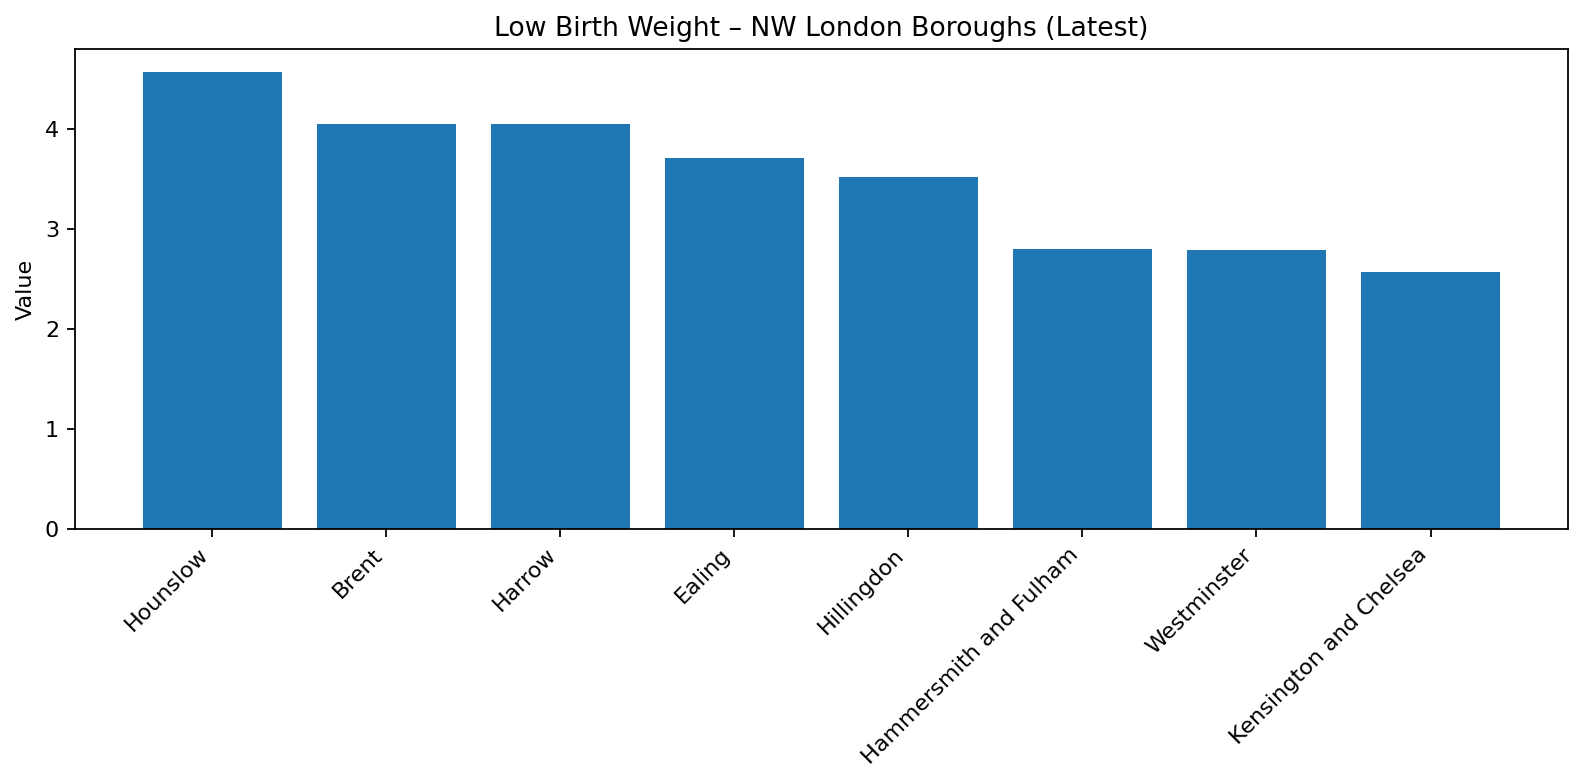

In [49]:
# Borough comparison plt construction by "3. Low Birth Weight"
plt.figure(figsize=(10, 5))
plt.bar(plot_df["borough"], plot_df["value"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Value")
plt.title("Low Birth Weight – NW London Boroughs (Latest)")
plt.tight_layout()
plt.show()

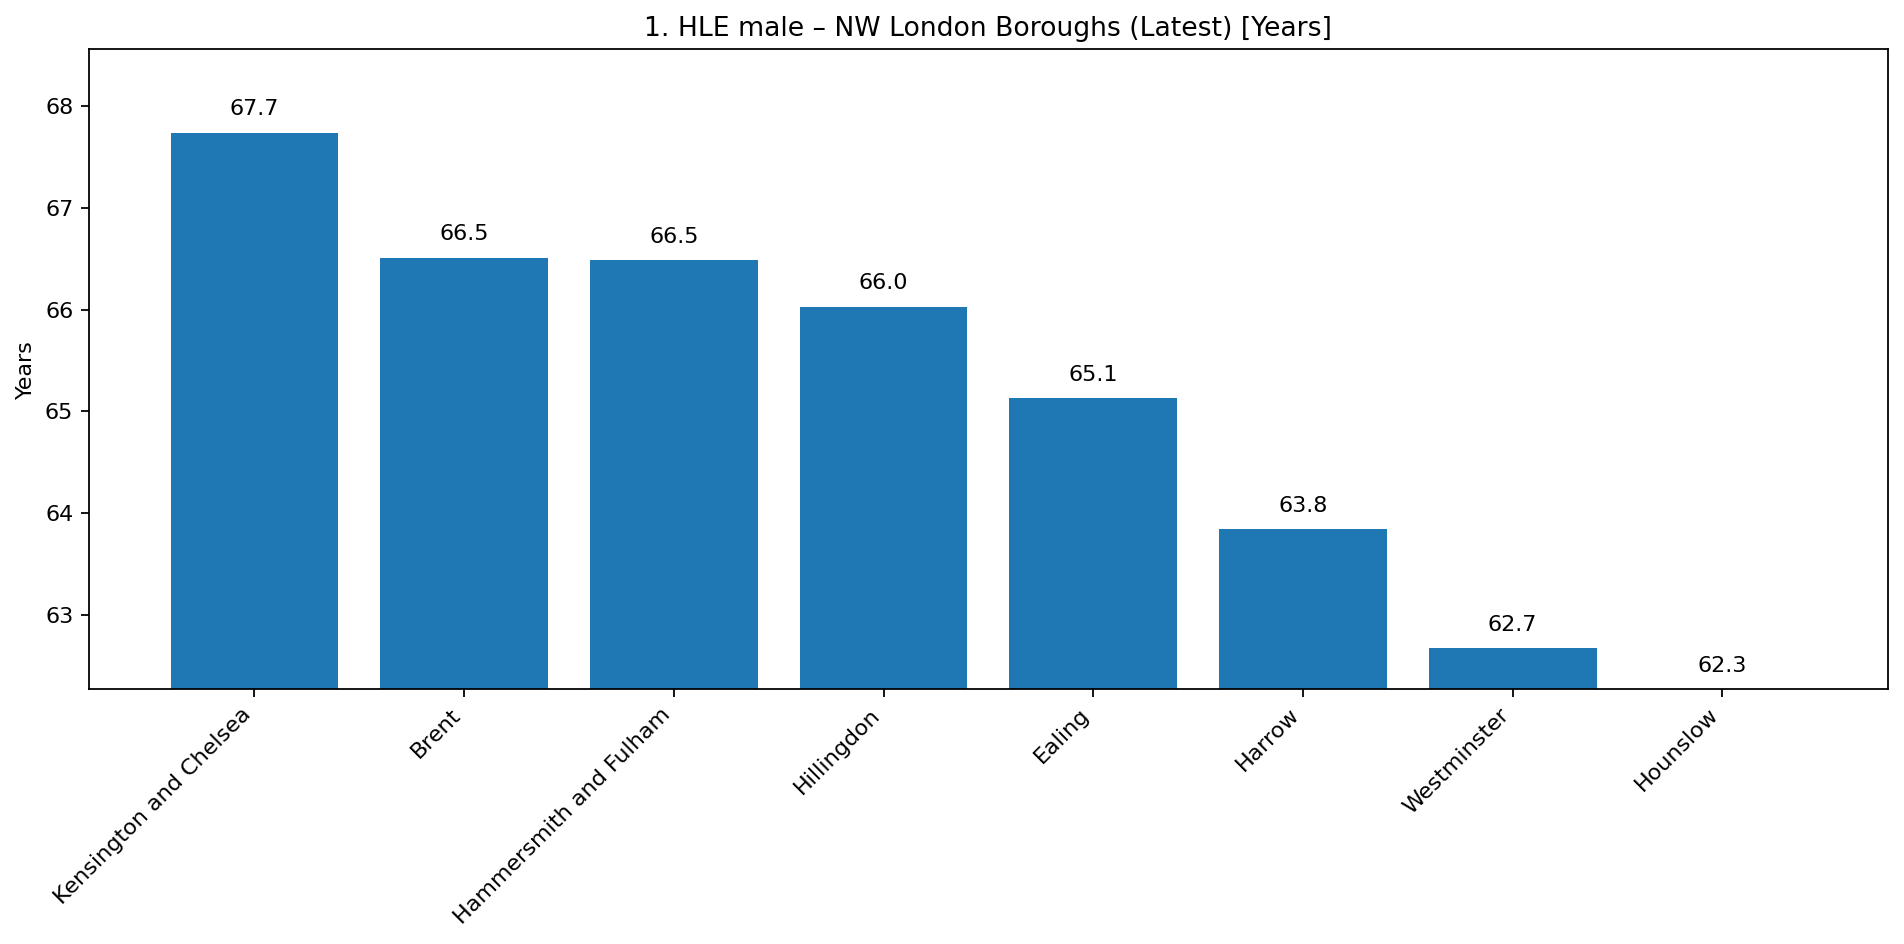

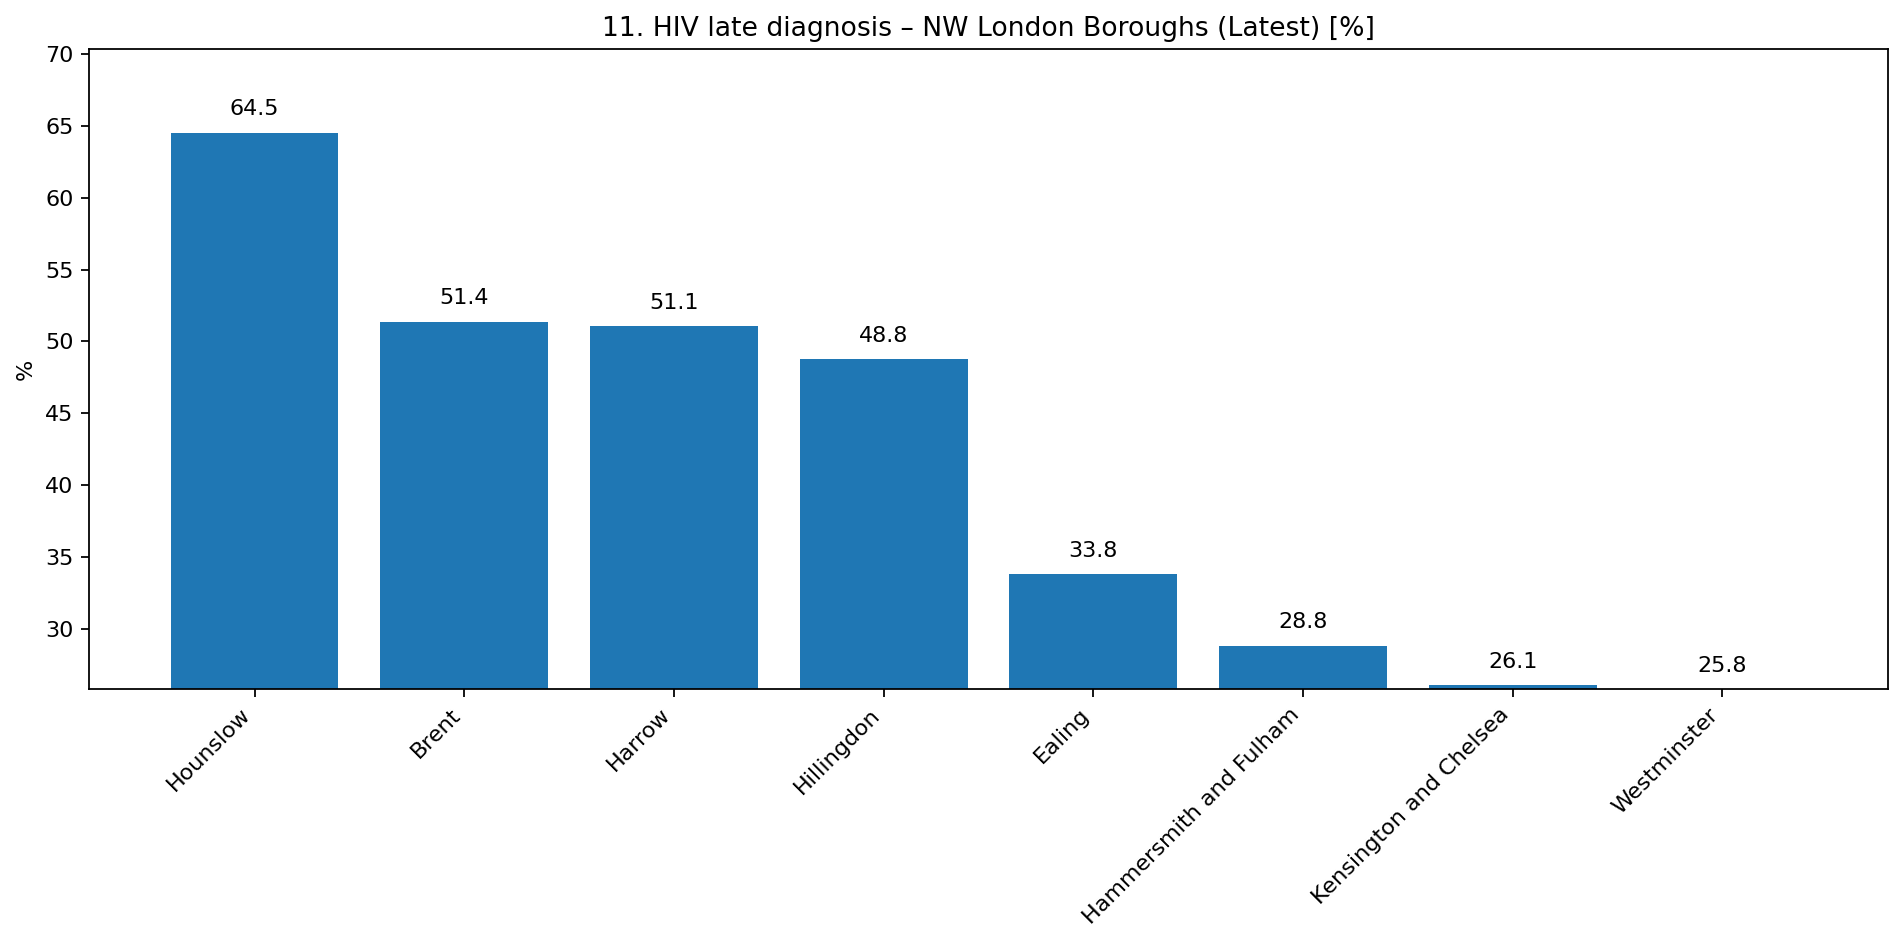

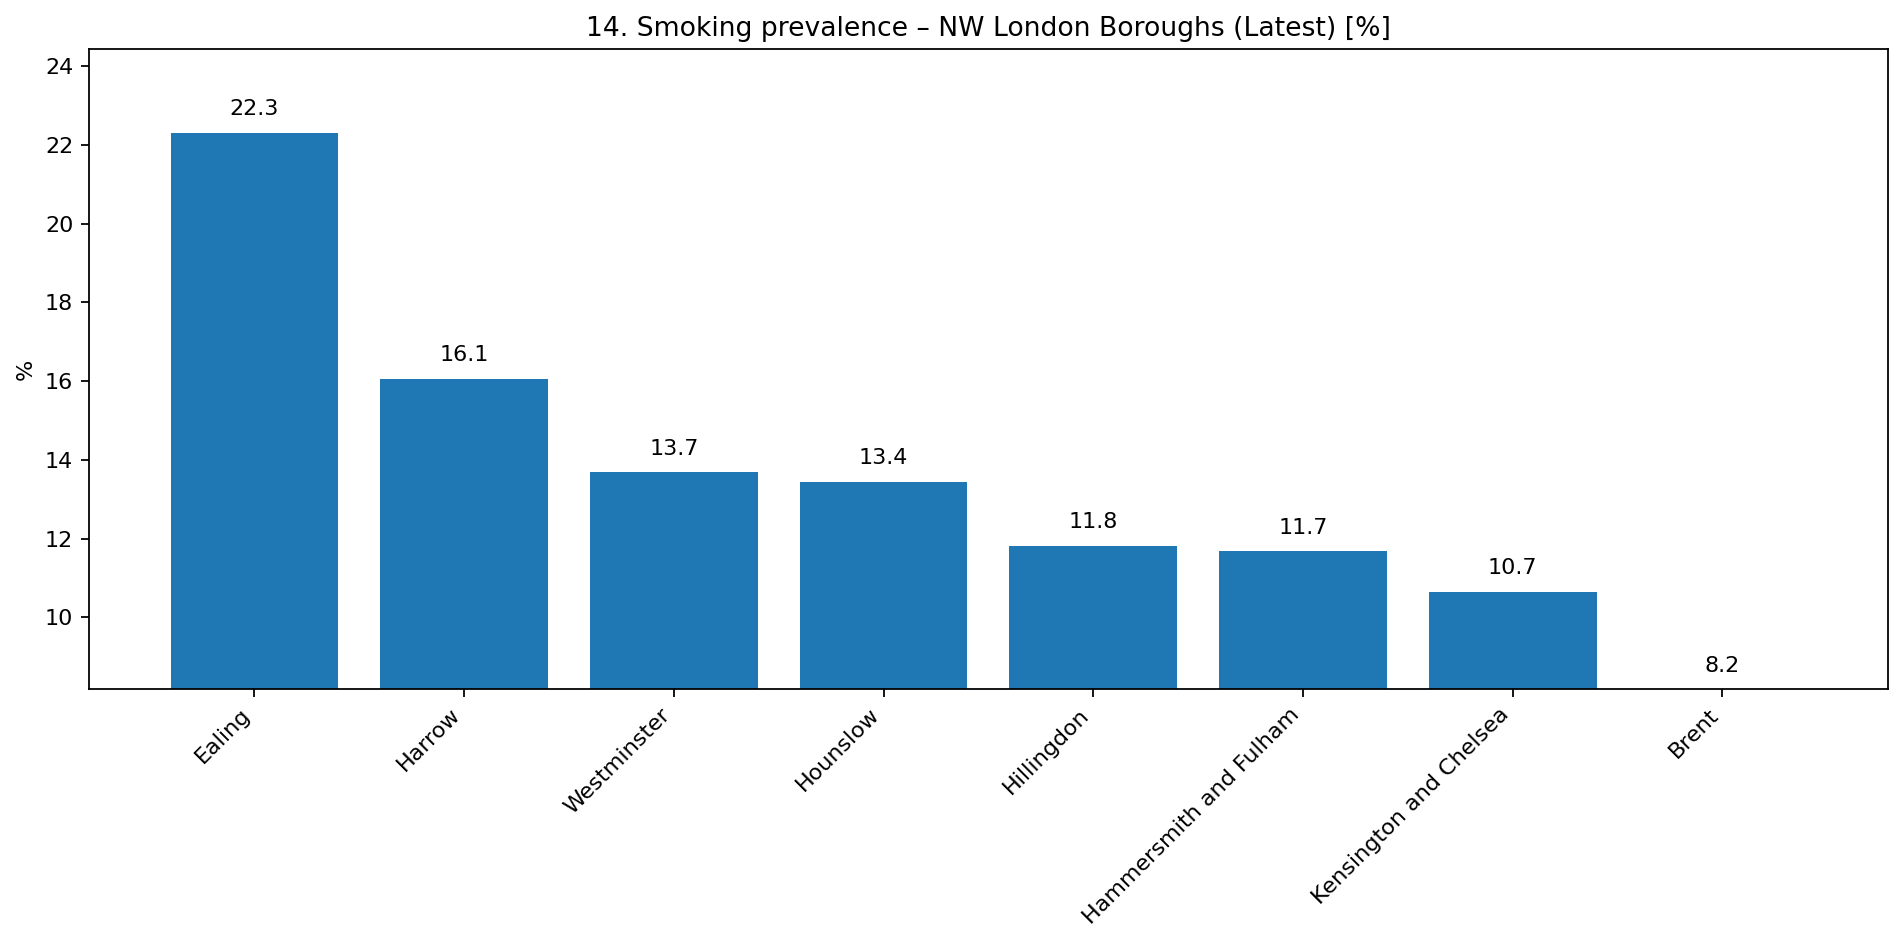

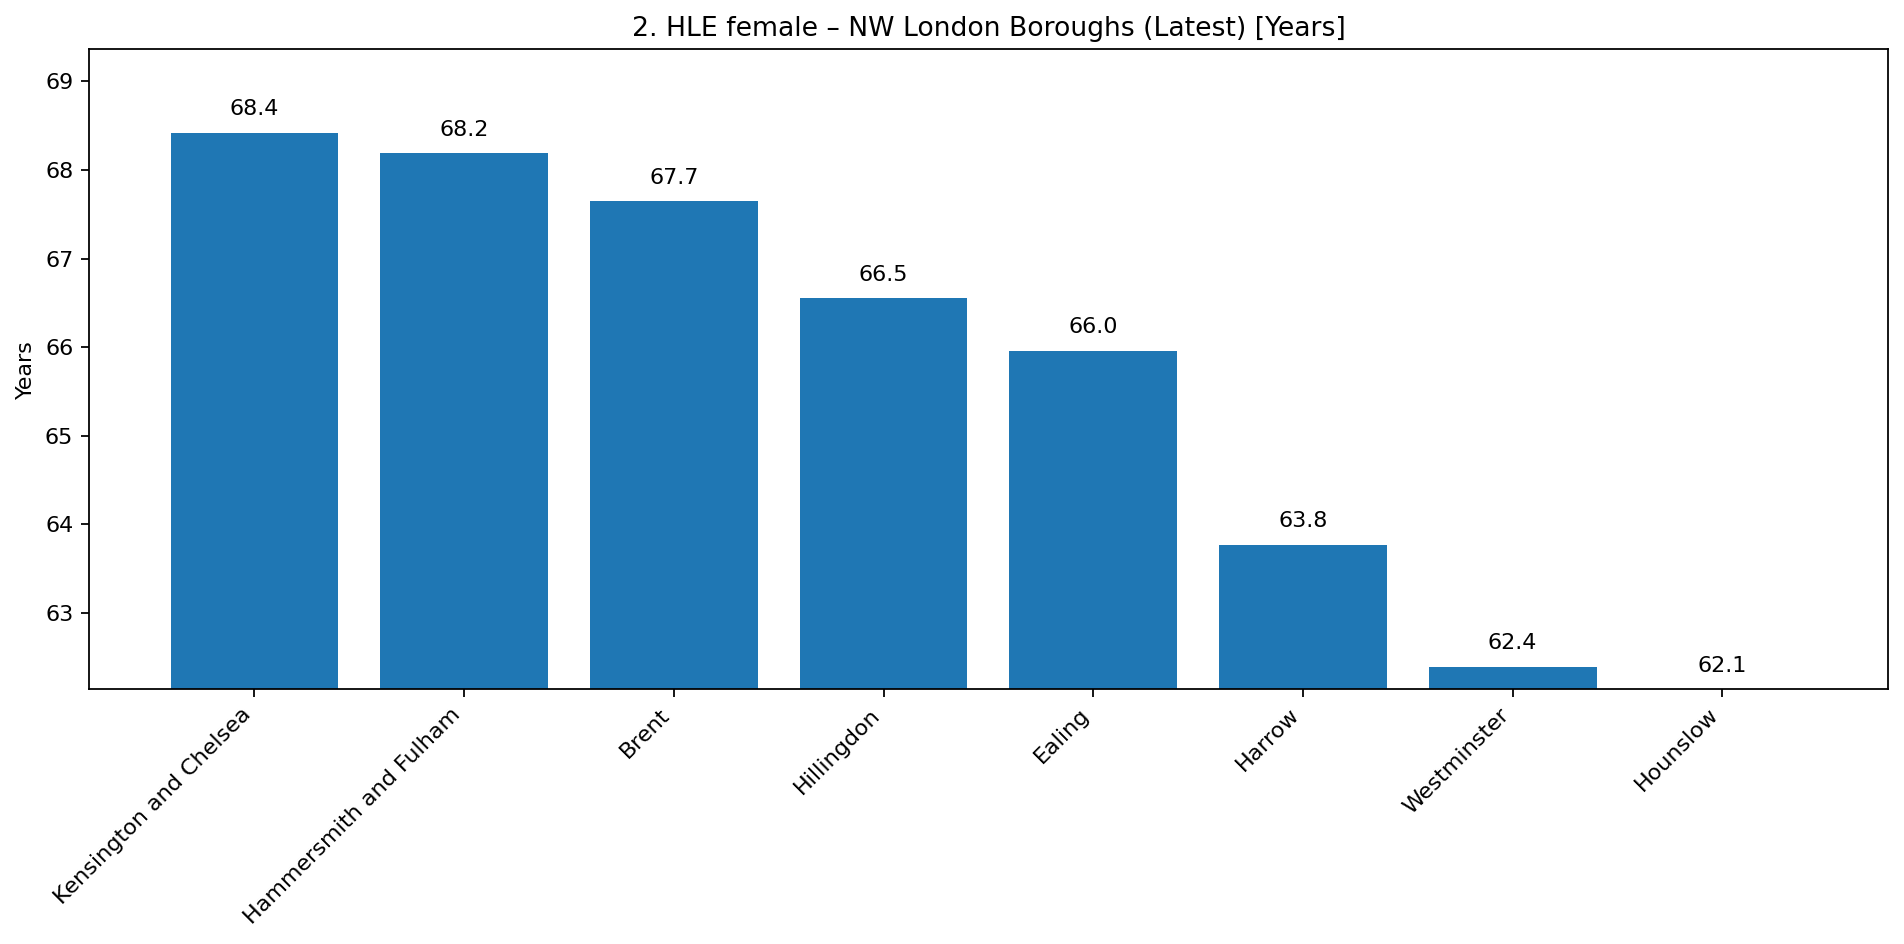

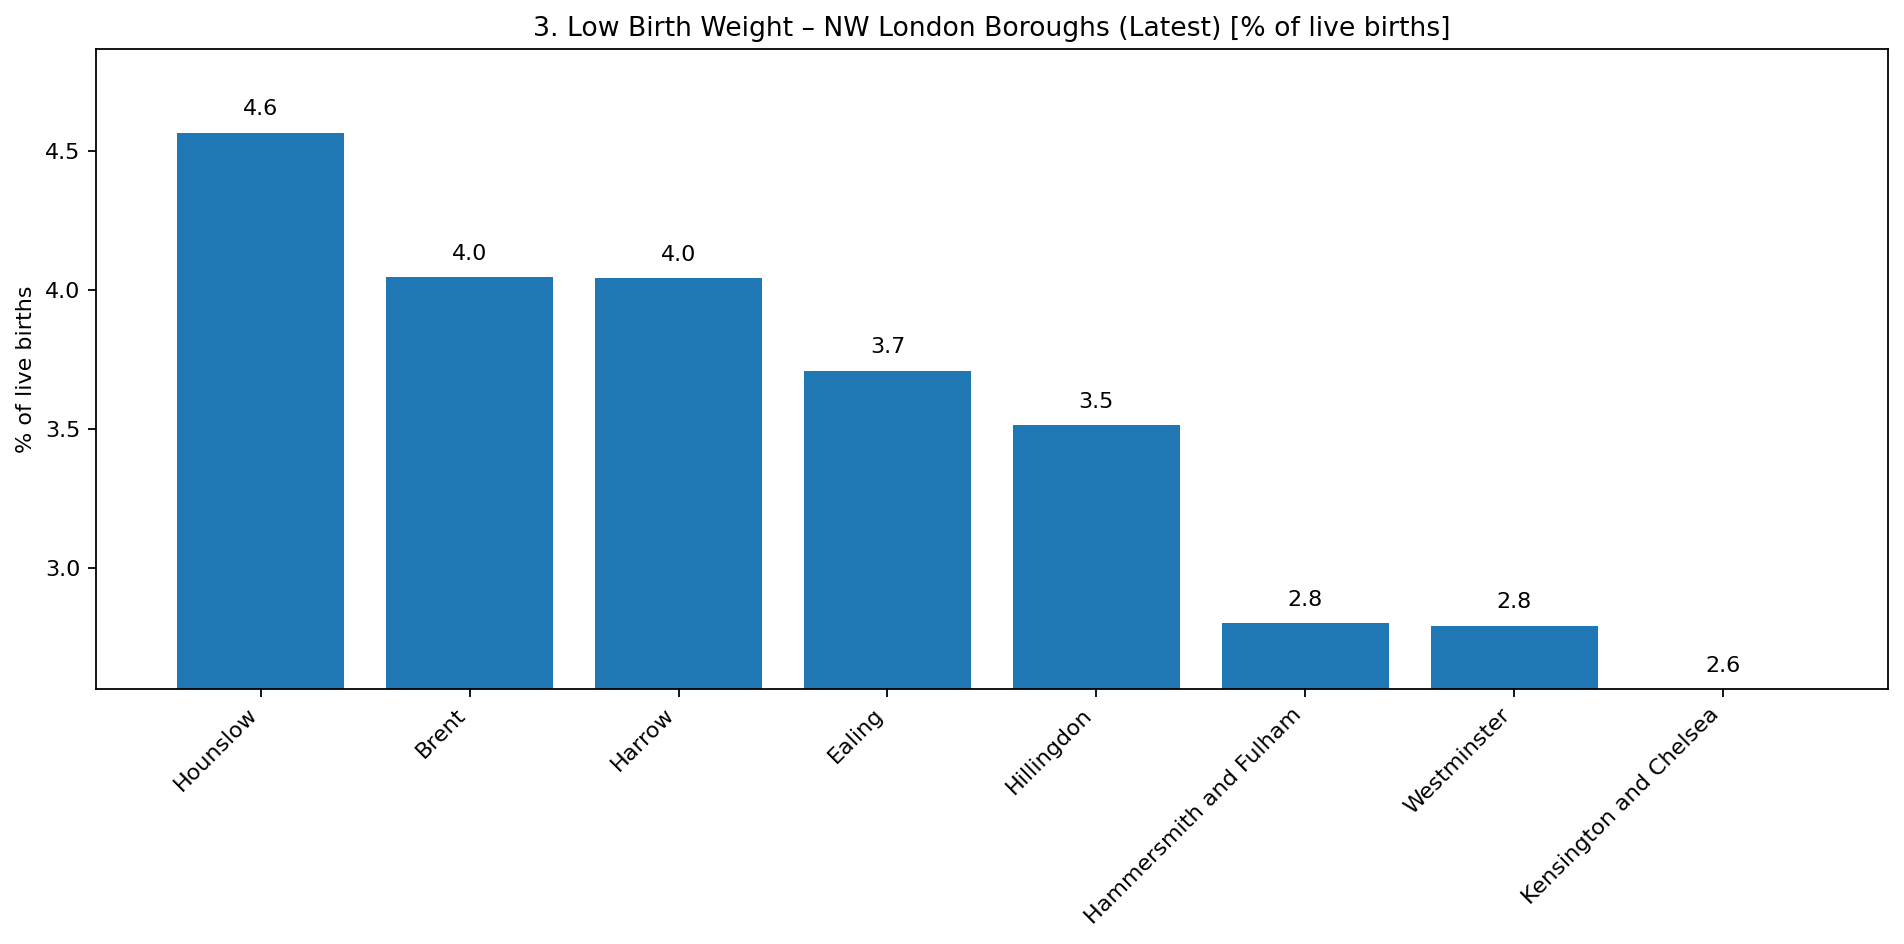

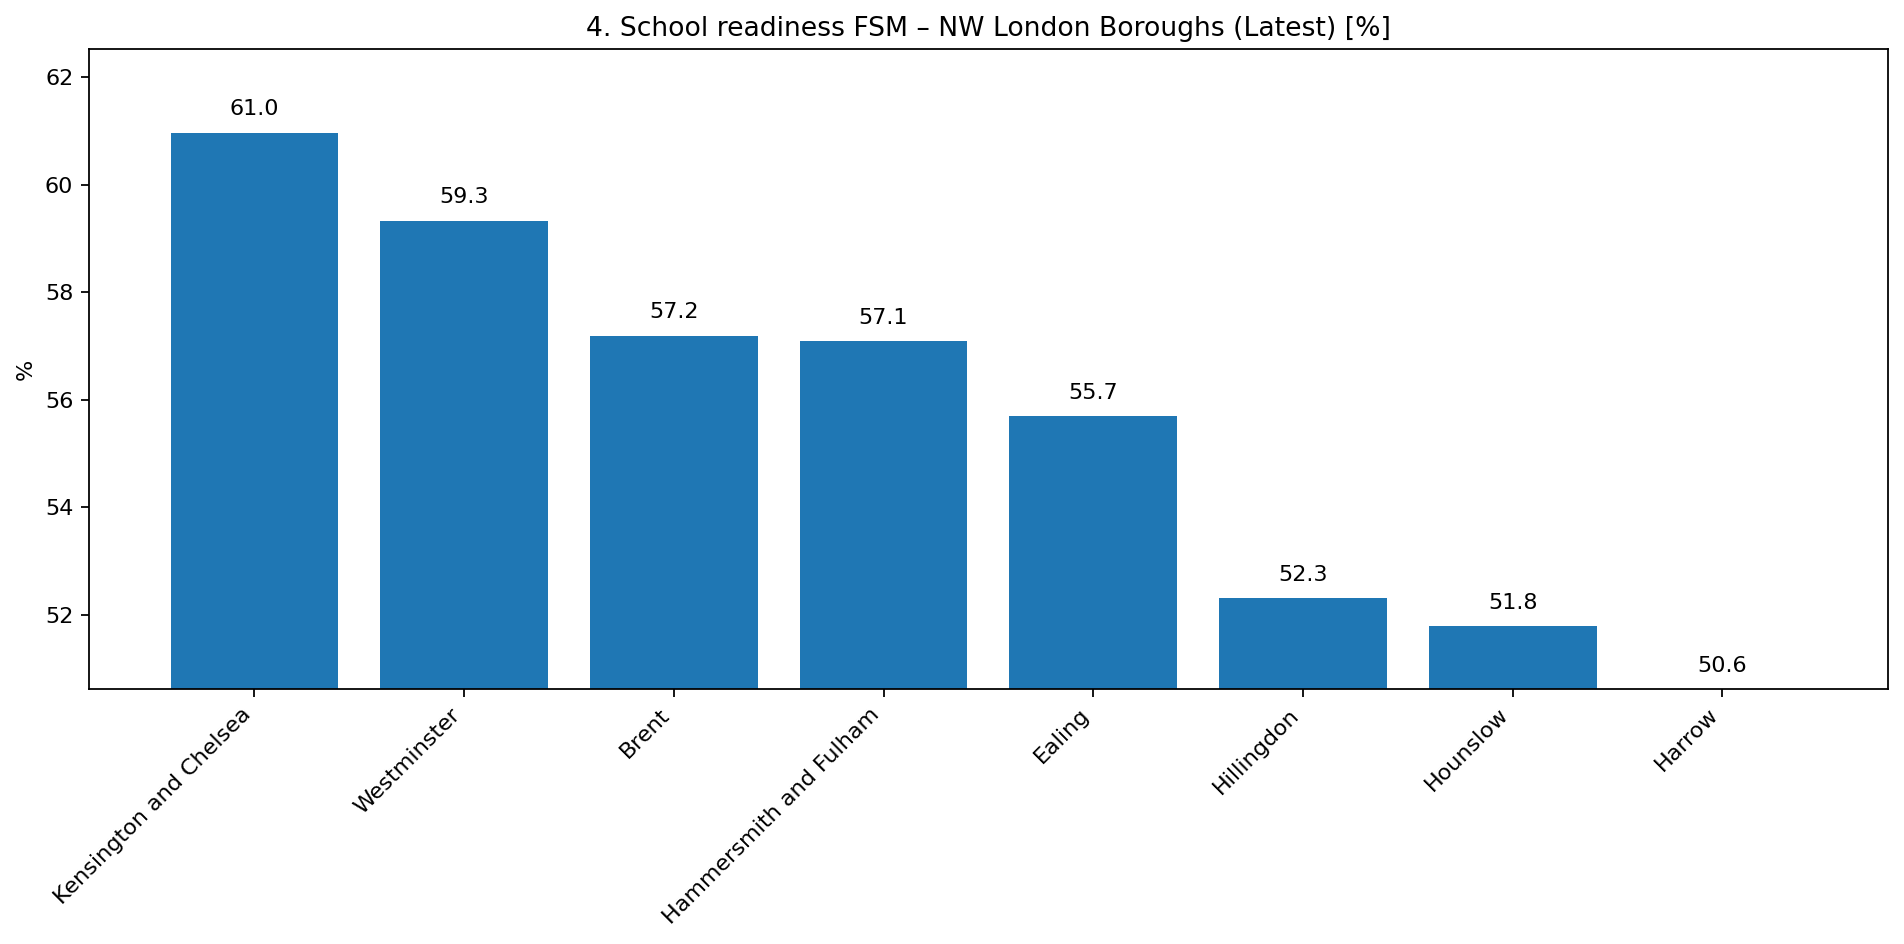

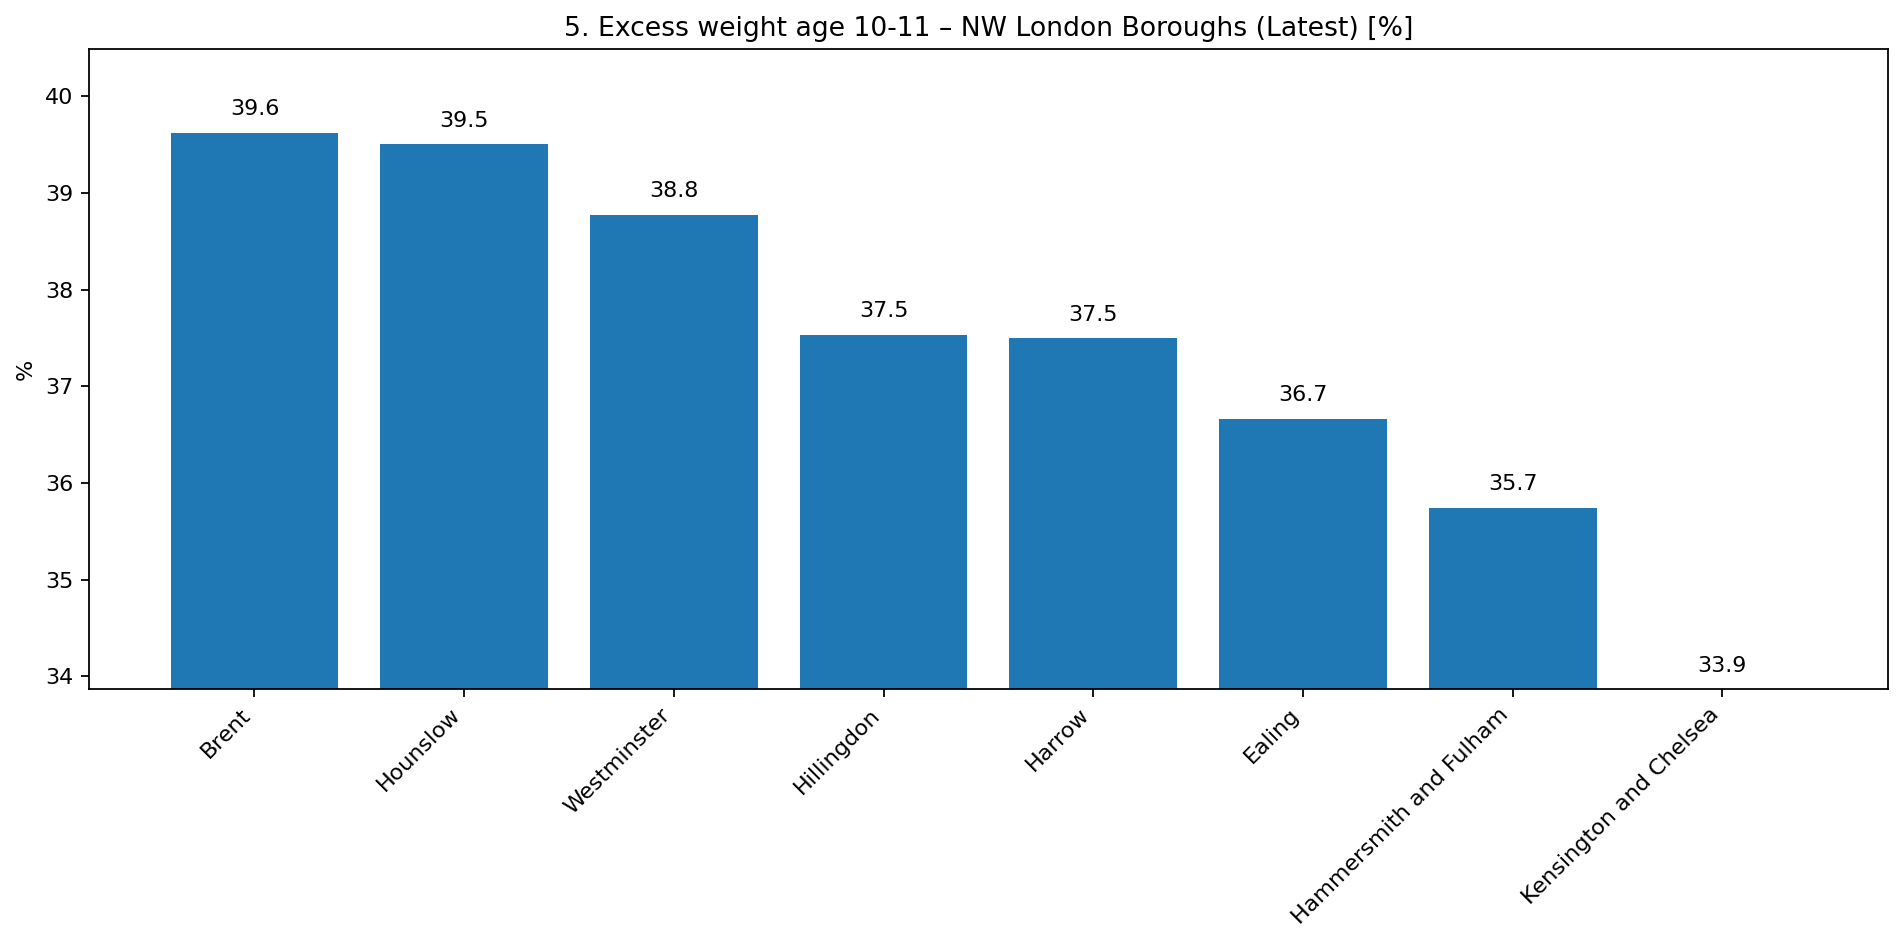

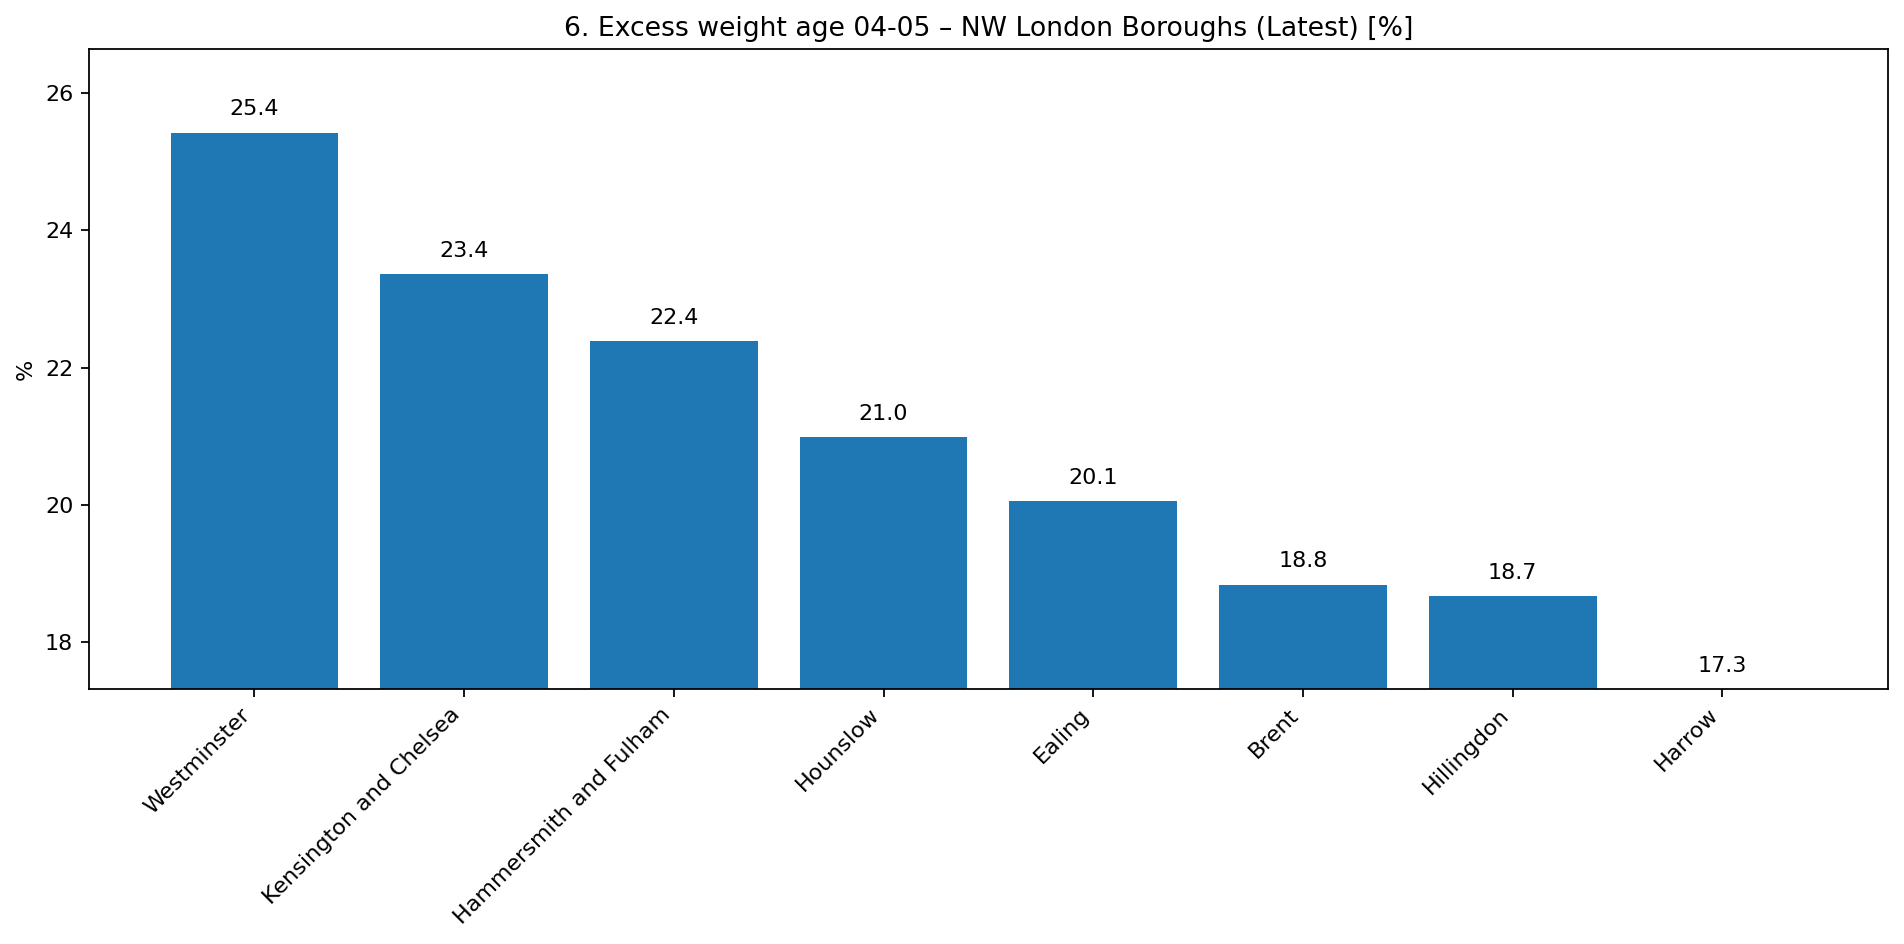

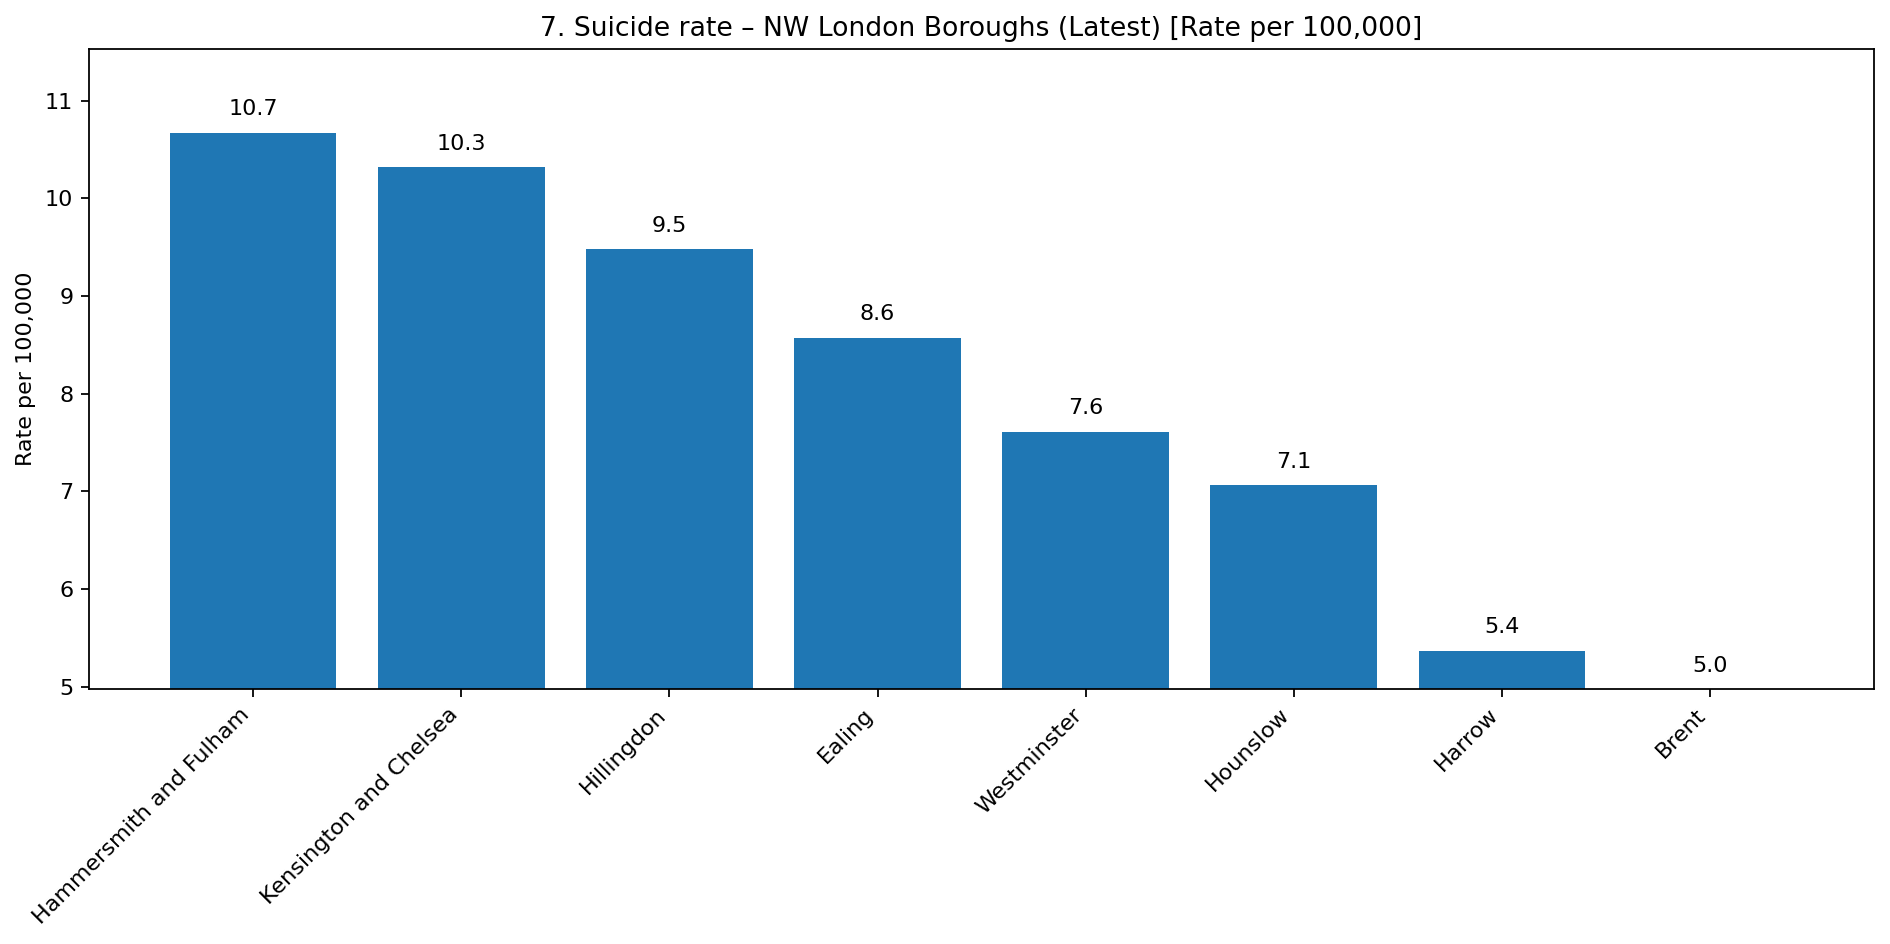

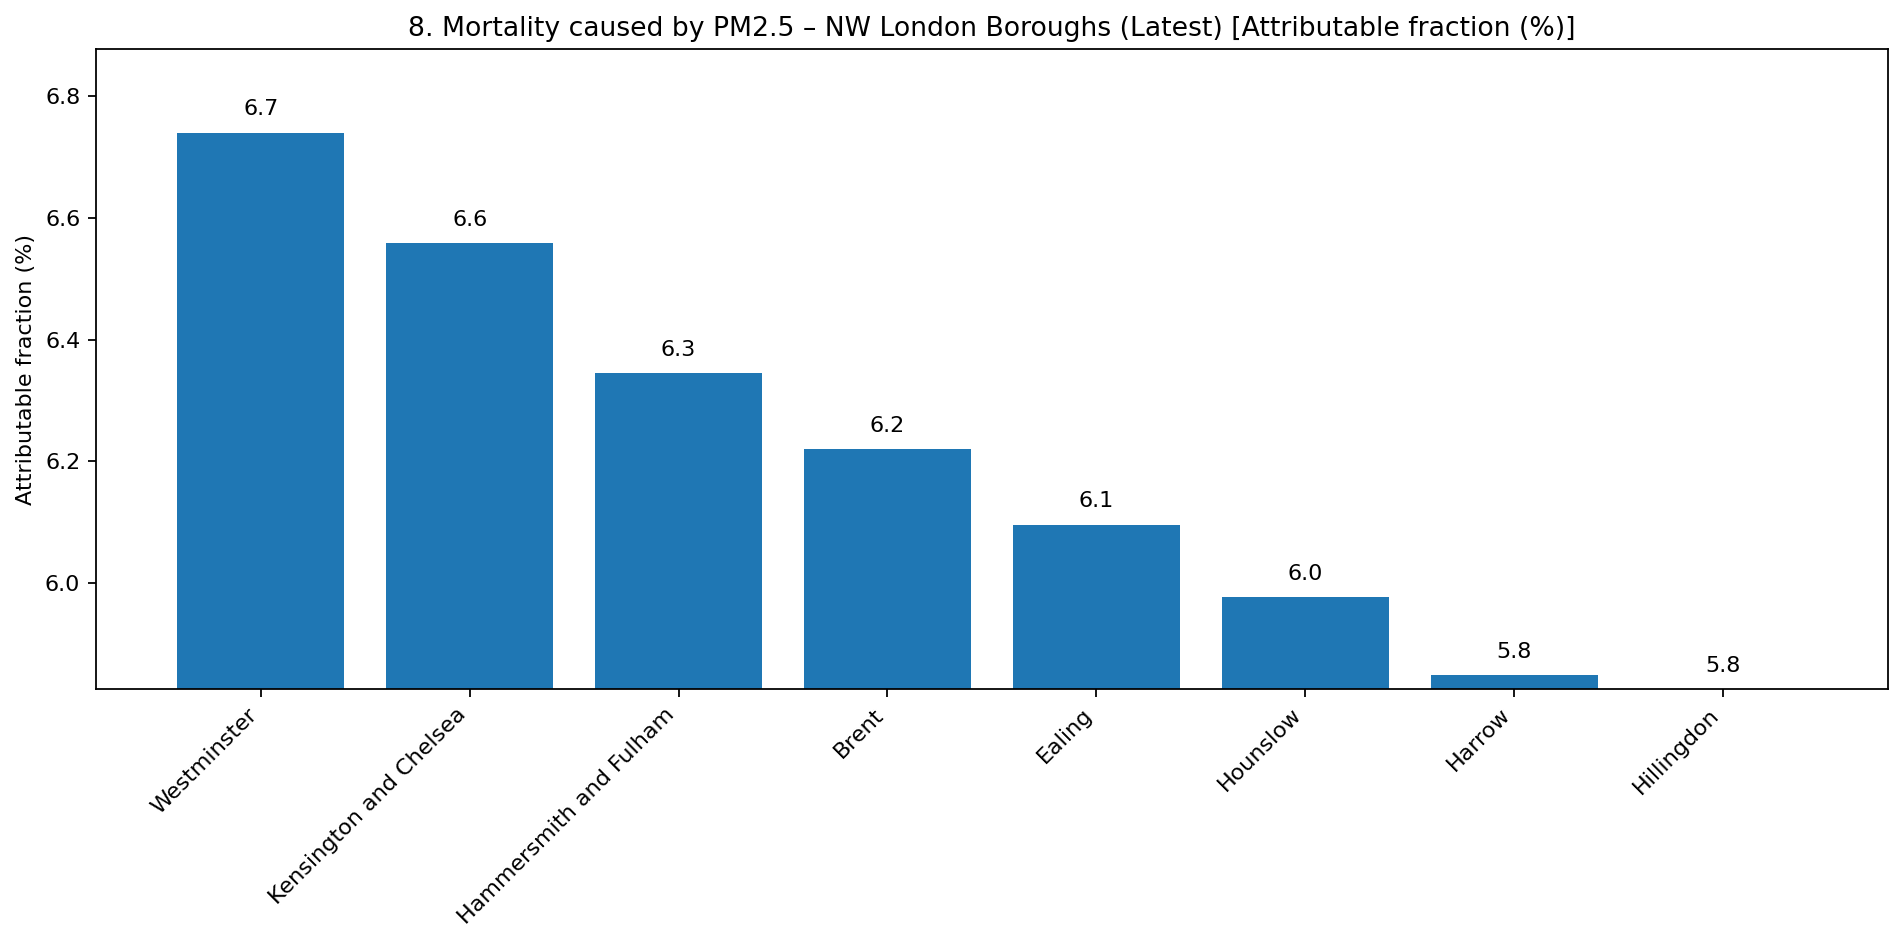

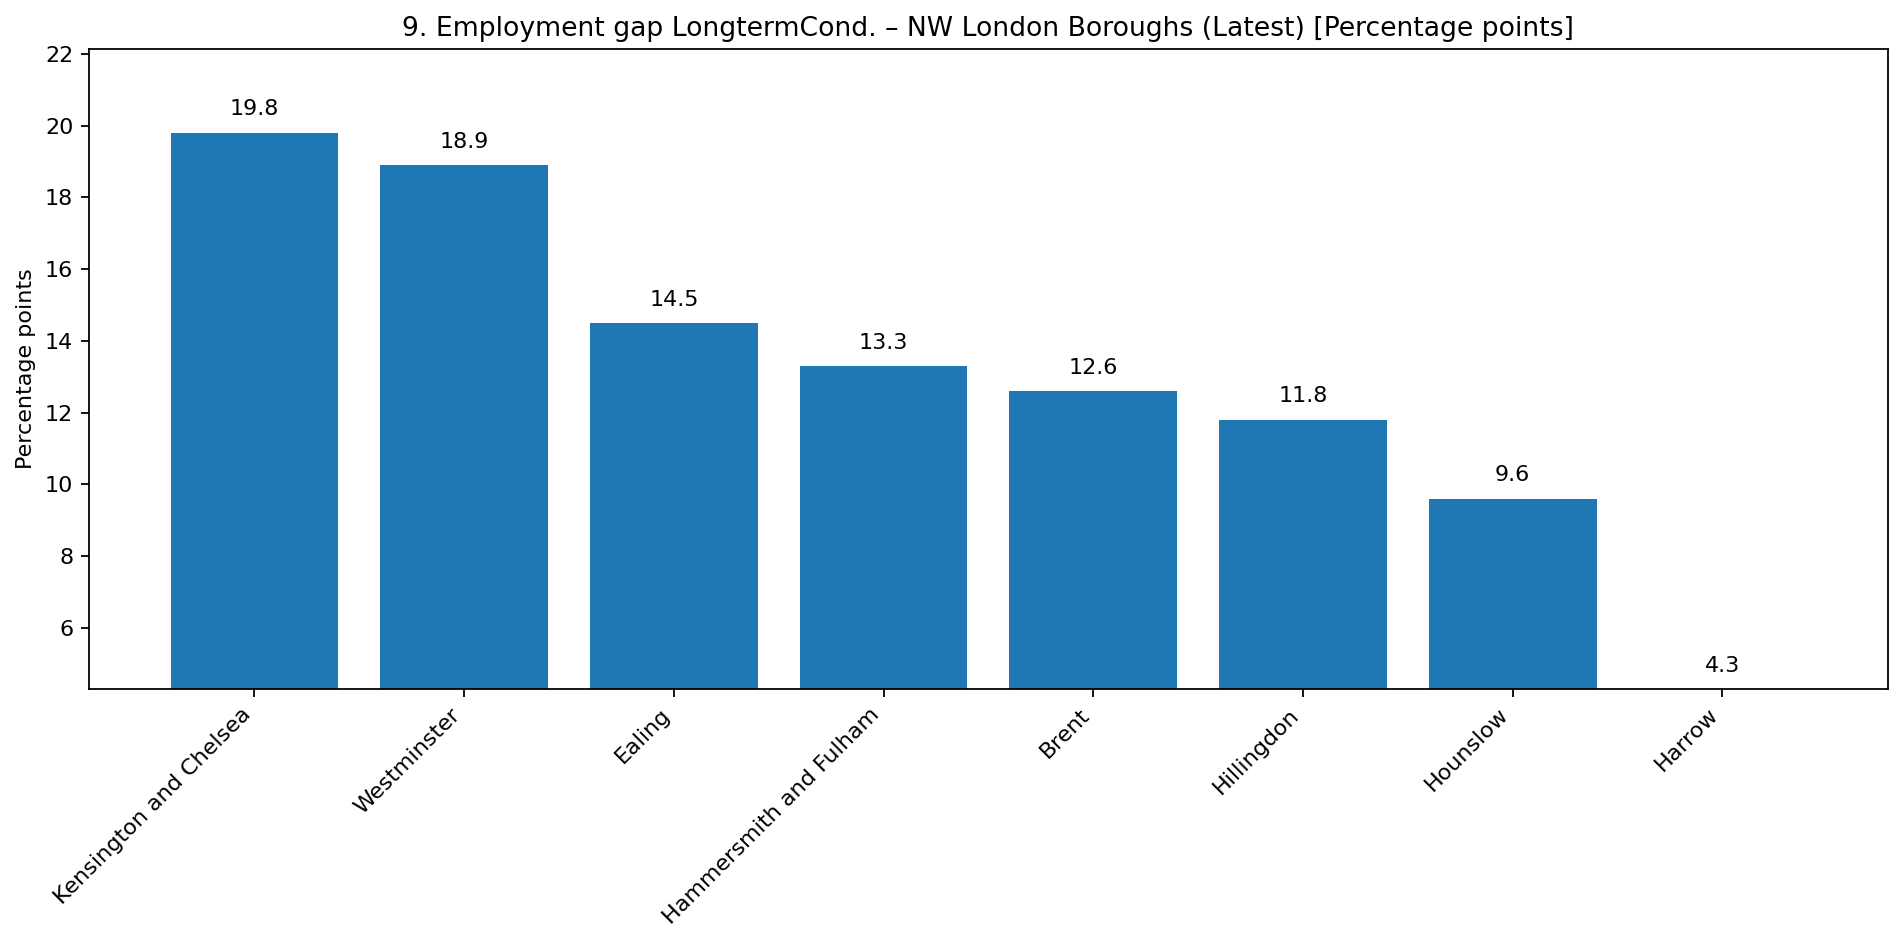

In [50]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["figure.dpi"] = 160
mpl.rcParams["savefig.dpi"] = 160

NWL_BOROUGHS = {
    "Brent",
    "Ealing",
    "Hammersmith and Fulham",
    "Harrow",
    "Hillingdon",
    "Hounslow",
    "Kensington and Chelsea",
    "Westminster",
}

HLE_SHEETS = {"1. HLE male", "2. HLE female"}

# Simple unit hints based on indicator sheet name (GLA HIS workbook)
UNIT_HINTS = [
    ("HLE", "Years"),
    ("Low Birth Weight", "% of live births"),
    ("School readiness", "%"),
    ("Excess weight", "%"),
    ("Suicide rate", "Rate per 100,000"),
    ("Mortality caused by PM2.5", "Attributable fraction (%)"),
    ("Employment gap", "Percentage points"),
    ("HIV late diagnosis", "%"),
    ("TB Incidence", "Rate per 100,000"),
    ("Smoking prevalence", "%"),
]

def unit_for_indicator(indicator_group: str) -> str:
    ind_lower = str(indicator_group).lower()
    for key, unit in UNIT_HINTS:
        if key.lower() in ind_lower:
            return unit
    return "Unit unknown"

indicators = sorted(gla["indicator_group"].dropna().unique())

for ind in indicators:
    df = gla[
        (gla["indicator_group"] == ind)
        & (gla["data_version"] == "latest")
        & (gla["borough"].isin(NWL_BOROUGHS))
    ].copy()

    if df.empty or df["borough"].nunique() < 5:
        continue

    # Fix HLE: keep only the most recent period, then one row per borough
    if ind in HLE_SHEETS and "time_period" in df.columns:
        df = df.dropna(subset=["value"]).copy()
        latest_period = df["time_period"].astype(str).value_counts().index[0]
        df = df[df["time_period"].astype(str) == latest_period].copy()
        df = df.groupby("borough", as_index=False)["value"].mean()

    df = df.dropna(subset=["value"]).copy()
    df = df.sort_values("value", ascending=False)

    unit = unit_for_indicator(ind)

    plt.figure(figsize=(12, 6))
    bars = plt.bar(df["borough"], df["value"])

    plt.xticks(rotation=45, ha="right")
    plt.ylabel(unit)
    plt.title(f"{ind} – NW London Boroughs (Latest) [{unit}]")

    # Add headroom so labels don't collide with the plot top
    y_min = float(df["value"].min())
    y_max = float(df["value"].max())
    pad = (y_max - y_min) * 0.15 if y_max != y_min else max(abs(y_max) * 0.15, 1.0)
    plt.ylim(y_min, y_max + pad)

    # Add value labels (readable)
    for bar in bars:
        height = bar.get_height()
        if pd.notna(height):
            plt.annotate(
                f"{height:.1f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 6),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=10,
                bbox=dict(facecolor="white", edgecolor="none", pad=1.5),
            )

    plt.tight_layout()
    plt.show()

### Percentage meaning in the datasets:  

- Low birth weight (%)

Denominator: live births in that borough (often term births only)

Interpretation:
7.1% = 7.1% of babies born in that borough had low birth weight

- Smoking prevalence (%)

Denominator: adults surveyed / modelled (usually 18+)

Interpretation:
12% = 12% of adults are smokers

- Excess weight (%)

Denominator: children measured (Reception or Year 6 cohorts)

Interpretation:
% of measured children who are overweight/obese

- School readiness (%)

Denominator: children assessed at Early Years stage

Interpretation:
% of children assessed who meet readiness threshold

- HIV late diagnosis (%)

Denominator: people diagnosed with HIV

Interpretation:
% of diagnosed cases that were late diagnoses